# **Data Visualization**

## Objectives

1. Answer Business Requirement 1:
   - Provide visual insights to differentiate between healthy and mildew-affected leaves. 
2. Visualize class distributions and image characteristics.
3. Generate visuals to aid in building the Streamlit dashboard.

## Inputs

- Dataset directories:
    - `inputs/mildew_dataset/cherry-leaves/train`
    - `inputs/mildew_dataset/cherry-leaves/validation`
    - `inputs/mildew_dataset/cherry-leaves/test`

## Outputs

- Image shape embeddings pickle file.
- Mean and variability of images per label plot.
- Visualization of class distributions.
- Image montage for use in the Streamlit dashboard.

## Additional Comments/Insights/Conclusions

- Visualizations provide clarity about data quality, balance, and structure. 
- Aids in designing effective preprocessing and modeling workflows.
- These visualizations ensure the dataset is ready for model training by highlighting class imbalances, image variability, and general data quality. 

---



# Set Up Environment

---

## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
sns.set_style("white")
from matplotlib.image import imread

## Set Working Directory 

In [2]:
cwd= os.getcwd()

In [3]:
os.chdir('/workspace/mildew-detection-app')
print("You set a new current directory")

You set a new current directory


In [7]:
work_dir = os.getcwd()
work_dir

'/workspace/mildew-detection-app'

## Set Input Directories

In [11]:
# Set data directories for train, validation and the test
my_data_dir = 'inputs/mildew_dataset/cherry-leaves'
train_path = my_data_dir + '/train'
val_path = my_data_dir + '/validation'
test_path = my_data_dir + '/test'

## Set Output Directory

In [12]:
version = 'v1'
file_path = f'outputs/{version}'

if 'outputs' in os.listdir(work_dir) and version in os.listdir(work_dir + '/outputs'):
    print('Old version is already available create a new version.')
    pass
else:
    os.makedirs(name=file_path)

Old version is already available create a new version.


### Set Label Names

In [13]:
# Set the labels for the images
labels = os.listdir(train_path)
print('Label for the images are', labels)

Label for the images are ['healthy', 'powdery_mildew']


---

## Data Visualiation of Image Data

---

## Image Shape

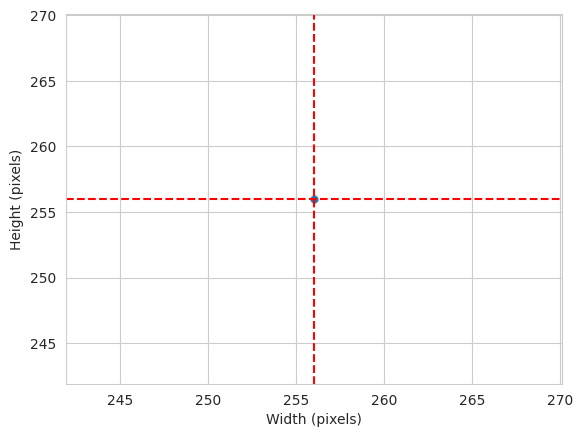

Width average: 256 
Height average: 256


In [14]:
# Compute average image dimensions on the train set
dim1, dim2 = [], []
for label in labels:
    for image_filename in os.listdir(train_path + '/' + label):
        img = imread(train_path + '/' + label + '/' + image_filename)
        d1, d2, colors = img.shape
        dim1.append(d1)  # image height
        dim2.append(d2)  # image width

# Plot image dimensions
sns.set_style("whitegrid")
fig, axes = plt.subplots()
sns.scatterplot(x=dim2, y=dim1, alpha=0.2)
axes.set_xlabel("Width (pixels)")
axes.set_ylabel("Height (pixels)")
dim1_mean = int(np.array(dim1).mean())
dim2_mean = int(np.array(dim2).mean())
axes.axvline(x=dim1_mean, color='r', linestyle='--')
axes.axhline(y=dim2_mean, color='r', linestyle='--')
plt.show()
print(f"Width average: {dim2_mean} \nHeight average: {dim1_mean}")

In [15]:
# Save average dimensions
image_shape = (dim1_mean, dim2_mean, 3)
image_shape

(256, 256, 3)

In [16]:
# Save the image shape embeddings
joblib.dump(value=image_shape ,
            filename=f"{file_path}/image_shape.pkl")

['outputs/v1/image_shape.pkl']

---

## Average and Variability of Images Per Label

---

Understanding the average and variability of images per class helps in identifying patterns or inconsistencies in the dataset.

### Function to load images into arrays

In [17]:
from tensorflow.keras.preprocessing import image


def load_image_as_array(my_data_dir, new_size=(50, 50), n_images_per_label=20):
    """
    Loads images as arrays for mean and variability visualization.
    """
    X, y = np.array([], dtype='int'), np.array([], dtype='object')
    labels = os.listdir(my_data_dir)

    for label in labels:
        counter = 0
        for image_filename in os.listdir(my_data_dir + '/' + label):
            # n_images_per_label: we set a limit, since it may take too much time
            if counter < n_images_per_label:

                img = image.load_img(
                    my_data_dir + '/' + label + '/' + image_filename, target_size=new_size)
                if image.img_to_array(img).max() > 1:
                    img_resized = image.img_to_array(img) / 255
                else:
                    img_resized = image.img_to_array(img)

                X = np.append(X, img_resized).reshape(-1,
                                                      new_size[0], new_size[1], img_resized.shape[2])
                y = np.append(y, label)
                counter += 1

    return X, y

2025-01-27 16:40:46.485668: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-27 16:40:46.748976: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load images as arrays

In [18]:
X, y = load_image_as_array(my_data_dir=train_path,
                           new_size=image_shape,
                           n_images_per_label=30)
print(X.shape, y.shape)

(60, 256, 256, 3) (60,)


### Plot mean and variability

In [19]:
def plot_mean_variability_per_labels(X, y, figsize=(12, 5), save_image=False):
    """
    The pseudo-code for the function is:
    * Iterate through all unique labels in the dataset.
    * Filter the dataset to include only images corresponding to the current label.
    * Calculate the mean and standard deviation for the filtered subset.
    * Create a figure with two subplots:
        - One displaying the mean image for the label.
        - The other showing the variability (standard deviation) image.
    * Optionally save the generated plots to the specified directory.
    """

    for label_to_display in np.unique(y):
        sns.set_style("white")  # Set the plot style

        # Reshape labels for compatibility and filter images for the current label
        y = y.reshape(-1, 1, 1)
        boolean_mask = np.any(y == label_to_display, axis=1).reshape(-1)
        arr = X[boolean_mask]

        # Compute the mean and variability for the current label
        avg_img = np.mean(arr, axis=0)
        std_img = np.std(arr, axis=0)
        print(f"==== Label {label_to_display} ====")
        print(f"Image Shape: {avg_img.shape}")

        # Create a figure to display the average and variability images
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=figsize)
        axes[0].set_title(f"Average image for label {label_to_display}")
        axes[0].imshow(avg_img, cmap='gray')
        axes[1].set_title(f"Variability image for label {label_to_display}")
        axes[1].imshow(std_img, cmap='gray')

        # Save or display the figure based on the `save_image` argument
        if save_image:
            plt.savefig(f"{file_path}/avg_var_{label_to_display}.png",
                        bbox_inches='tight', dpi=150)
        else:
            plt.tight_layout()  # Adjust layout for better spacing
            plt.show()
            print("\n")

==== Label healthy ====
Image Shape: (256, 256, 3)
==== Label powdery_mildew ====
Image Shape: (256, 256, 3)


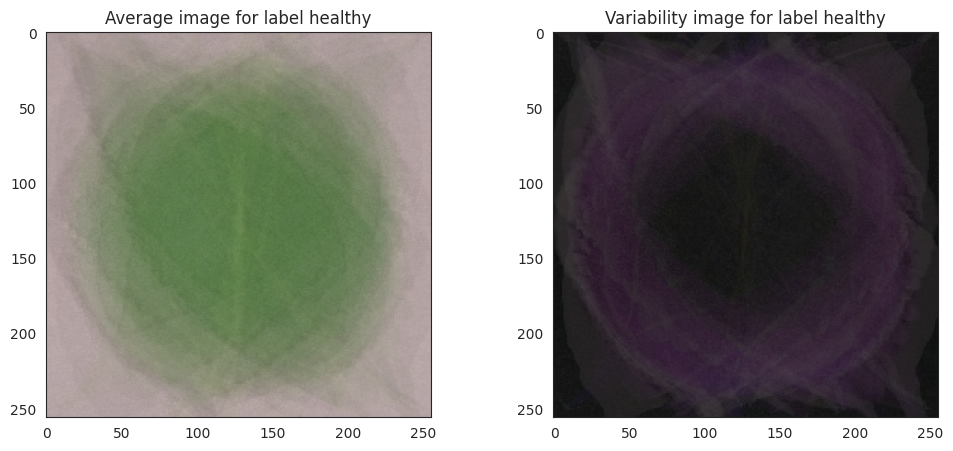

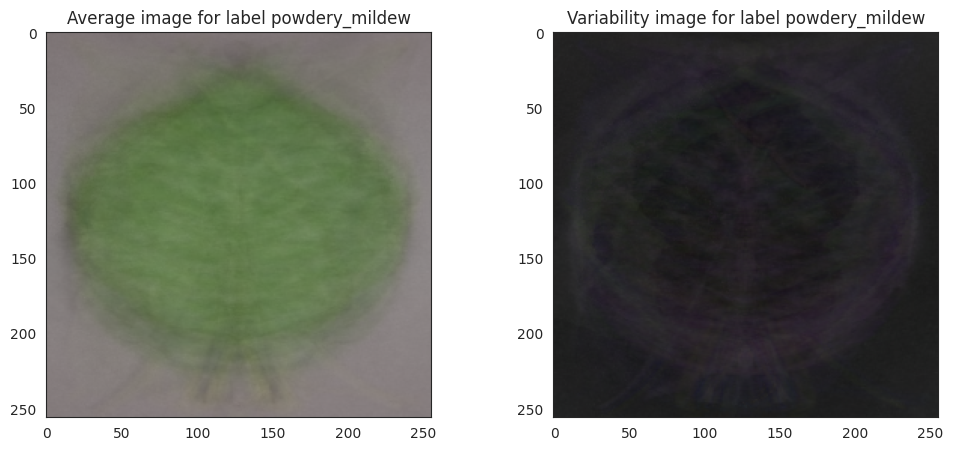

In [20]:
plot_mean_variability_per_labels(X=X, y=y, figsize=(12, 5), save_image=True)

---

### Difference between average healthy and mildew-affected leaves

In [21]:
def subset_image_label(X, y, label_to_display):
    """
    Filters the dataset to include only the images that belong to a specific label.
    """

    # Reshape the labels for compatibility and filter for the given label
    y = y.reshape(-1, 1, 1)
    y = y.reshape(-1, 1, 1)
    boolean_mask = np.any(y == label_to_display, axis=1).reshape(-1)
    df = X[boolean_mask]  # Subset the dataset
    return df


def diff_bet_avg_image_labels_data_as_array(X, y, label_1, label_2, figsize=(20, 5), save_image=False):
    """
    Compares the average images between two specified labels.

    - Verifies that both labels exist in the dataset.
    - Calculates the mean image for each label.
    - Computes the difference between the two mean images.
    - Displays or optionally saves a figure with:
        * Average image for label_1
        * Average image for label_2
        * Difference between the two averages
    """
    sns.set_style("white")

    # Validate that both labels are present in the dataset
    if (label_1 not in np.unique(y)) or (label_2 not in np.unique(y)):
        print(
            f"Either label {label} or label {label_2}, are not in {np.unique(y)} ")
        return

    # Calculate mean from label_1
    images_label = subset_image_label(X, y, label_1)
    label1_avg = np.mean(images_label, axis=0)

    # Calculate mean from label_2
    images_label = subset_image_label(X, y, label_2)
    label2_avg = np.mean(images_label, axis=0)

    # Compute the difference between the two mean images
    difference_mean = label1_avg - label2_avg

    # Create and display a plot with the results
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)
    axes[0].imshow(label1_avg, cmap='gray')
    axes[0].set_title(f'Average {label_1}')
    axes[1].imshow(label2_avg, cmap='gray')
    axes[1].set_title(f'Average {label_2}')
    axes[2].imshow(difference_mean, cmap='gray')
    axes[2].set_title(f'Difference image: Avg {label_1} & {label_2}')

    # Save the plot to a file if save_image=True, otherwise display it
    if save_image:
        plt.savefig(f"{file_path}/avg_diff.png", bbox_inches='tight', dpi=150)
    else:
        plt.tight_layout()
        plt.show()

In [ ]:
diff_bet_avg_image_labels_data_as_array(X=X, y=y,
                                        label_1='Healthy', label_2='powdery_mildew',
                                        figsize=(12, 10),
                                        save_image=True
                                        )

## Image Montage

In [ ]:
import itertools
import random
sns.set_style("white")


def image_montage(dir_path, label_to_display, nrows, ncols, figsize=(15, 10)):
    """
    - Verify if the specified label exists in the directory.
    - Ensure the grid size (nrows * ncols) does not exceed the number of available images.
    - Generate a list of indices for placing images in the grid based on the specified rows and columns.
    - Create a figure to display the images, loading and plotting each in the respective grid space.
    """

    labels = os.listdir(dir_path)

    # Check if the specified label exists in the directory
    if label_to_display in labels:

        # Validate that the montage grid can fit the available images
        images_list = os.listdir(dir_path + '/' + label_to_display)
        if nrows * ncols < len(images_list):
            img_idx = random.sample(images_list, nrows * ncols)
        else:
            print(
                f"Reduce the number of rows or columns for the montage. \n"
                f"There are only {len(images_list)} images available. "
                f"You requested a grid for {nrows * ncols} images.")
            return

        # Generate grid indices based on the number of rows and columns
        list_rows = range(0, nrows)
        list_cols = range(0, ncols)
        plot_idx = list(itertools.product(list_rows, list_cols))

        # Create a figure and populate it with the selected images
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
        for x in range(0, nrows * ncols):
            img = imread(dir_path + '/' + label_to_display + '/' + img_idx[x])
            img_shape = img.shape
            axes[plot_idx[x][0], plot_idx[x][1]].imshow(img)
            axes[plot_idx[x][0], plot_idx[x][1]].set_title(
                f"Width: {img_shape[1]}px, Height: {img_shape[0]}px")
            axes[plot_idx[x][0], plot_idx[x][1]].set_xticks([])
            axes[plot_idx[x][0], plot_idx[x][1]].set_yticks([])
        plt.tight_layout()
        plt.show()

    else:
        # Notify the user if the selected label does not exist
        print(f"The selected label '{label_to_display}' does not exist.")
        print(f"Available labels are: {labels}")

### Run Montage

In [ ]:
for label in labels:
    print(label)
    image_montage(dir_path=train_path,
                  label_to_display=label,
                  nrows=3, ncols=3,
                  figsize=(10, 15)
                  )
    print("\n")